Saving fashion_productss.csv to fashion_productss.csv
Dataset loaded successfully!

First 5 Rows:
   User ID  Product ID Product Name   Brand         Category  Price    Rating  \
0       19           1        Dress  Adidas    Men's Fashion     40  1.043159   
1       97           2        Shoes     H&M  Women's Fashion     82  4.026416   
2       25           3        Dress  Adidas  Women's Fashion     44  3.337938   
3       57           4        Shoes    Zara    Men's Fashion     23  1.049523   
4       79           5      T-shirt  Adidas    Men's Fashion     79  4.302773   

    Color Size  
0   Black   XL  
1   Black    L  
2  Yellow   XL  
3   White    S  
4   Black    M  

Dataset Shape:
(1000, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User ID       1000 non-null   int64  
 1   Product ID    1000 non-nul

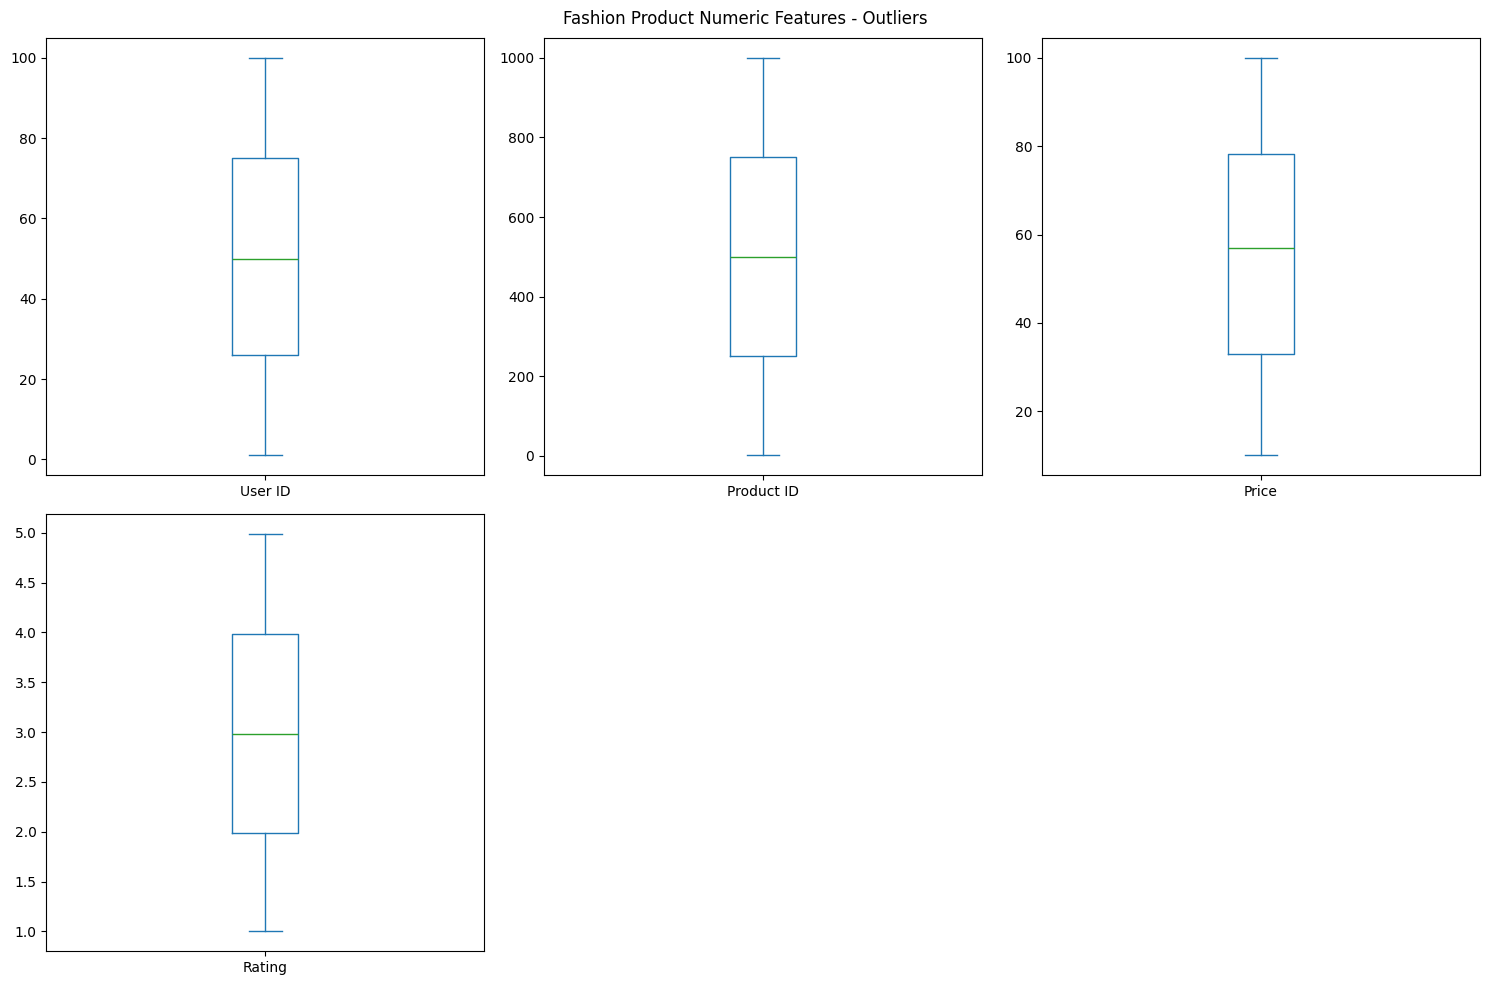


Outliers handled using IQR capping.

DATA SCALING

Scaled Numeric Data:
    User ID  Product ID     Price    Rating
0  0.181818    0.000000  0.333333  0.010582
1  0.969697    0.001001  0.800000  0.758829
2  0.242424    0.002002  0.377778  0.586148
3  0.565657    0.003003  0.144444  0.012179
4  0.787879    0.004004  0.766667  0.828144

LABEL ENCODING

Category encoded successfully.
   Category
0         1
1         2
2         2
3         1
4         1

ONE-HOT ENCODING

Categorical columns selected for One-Hot Encoding:
['Product Name', 'Brand', 'Color', 'Size']

Data after One-Hot Encoding:
    User ID  Product ID  Category     Price    Rating  Product Name_Jeans  \
0  0.181818    0.000000         1  0.333333  0.010582                   0   
1  0.969697    0.001001         2  0.800000  0.758829                   0   
2  0.242424    0.002002         2  0.377778  0.586148                   0   
3  0.565657    0.003003         1  0.144444  0.012179                   0   
4  0.787879    

In [1]:
# ============================================================
# FASHION PRODUCT ANALYSIS
# DATA CLEANING AND PREPROCESSING
# ============================================================


# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder


# ============================================================
# LOAD DATASET
# ============================================================

# If you are using Google Colab, upload your CSV file

from google.colab import files

uploaded = files.upload()

# Automatically get uploaded filename

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)


# ============================================================
# DATA UNDERSTANDING
# ============================================================

print("Dataset loaded successfully!")

print("\nFirst 5 Rows:")
print(df.head())


print("\nDataset Shape:")
print(df.shape)


print("\nDataset Information:")
df.info()


print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

# Separate numeric and categorical columns

numeric_cols = df.select_dtypes(
    include=np.number
).columns

categorical_cols = df.select_dtypes(
    include="object"
).columns


# Fill numeric missing values with median

for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )


# Fill categorical missing values with mode

for col in categorical_cols:

    if df[col].isnull().sum() > 0:

        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(
                mode_value[0]
            )
        else:
            df[col] = df[col].fillna(
                "Unknown"
            )


print("\nMissing Values After Filling:")
print(df.isnull().sum())


# ============================================================
# DUPLICATE ROWS
# ============================================================

print("\nDuplicate Rows :", df.duplicated().sum())


# Remove duplicate rows

df.drop_duplicates(
    inplace=True
)


print(
    "After Duplicate Removal :",
    df.shape
)


# ============================================================
# OUTLIER DETECTION
# ============================================================

print("\n==============================")
print("OUTLIER DETECTION")
print("==============================")


# Find numeric columns again

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()


# Detect outliers using IQR

outlier_summary = {}


for col in numeric_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    outlier_summary[col] = len(outliers)


print("\nNumber of Outliers in Each Numeric Column:")

for col, count in outlier_summary.items():

    print(
        col,
        ":",
        count
    )


# ============================================================
# OUTLIER VISUALIZATION
# ============================================================

# Show boxplots for numeric columns

if len(numeric_cols) > 0:

    df[numeric_cols].plot(
        kind="box",
        subplots=True,
        layout=(
            int(np.ceil(len(numeric_cols) / 3)),
            3
        ),
        figsize=(15, 10),
        sharex=False,
        sharey=False
    )

    plt.suptitle(
        "Fashion Product Numeric Features - Outliers"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# REMOVE EXTREME OUTLIERS
# ============================================================

# Instead of deleting rows, cap extreme values
# using IQR limits. This keeps the dataset size stable.

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower,
        upper=upper
    )


print("\nOutliers handled using IQR capping.")


# ============================================================
# NORMALIZATION / SCALING
# ============================================================

print("\n==============================")
print("DATA SCALING")
print("==============================")


# Select numeric columns

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()


# Min-Max Scaling

scaler = MinMaxScaler()


df[numeric_cols] = scaler.fit_transform(
    df[numeric_cols]
)


print("\nScaled Numeric Data:")

print(
    df[numeric_cols].head()
)


# ============================================================
# LABEL ENCODING
# ============================================================

print("\n==============================")
print("LABEL ENCODING")
print("==============================")


# If Category column exists,
# encode it as the target variable.

if "Category" in df.columns:

    encoder = LabelEncoder()

    df["Category"] = encoder.fit_transform(
        df["Category"].astype(str)
    )

    print(
        "\nCategory encoded successfully."
    )

    print(
        df[["Category"]].head()
    )

else:

    print(
        "\nCategory column not found."
    )

    print(
        "Available categorical columns:"
    )

    print(
        df.select_dtypes(
            include="object"
        ).columns.tolist()
    )


# ============================================================
# ONE-HOT ENCODING
# ============================================================

print("\n==============================")
print("ONE-HOT ENCODING")
print("==============================")


# Find remaining categorical columns

categorical_cols = df.select_dtypes(
    include="object"
).columns.tolist()


# Avoid very high-cardinality text columns
# such as Product Name, Description, etc.

one_hot_cols = []

for col in categorical_cols:

    unique_count = df[col].nunique()

    if unique_count <= 30:

        one_hot_cols.append(col)


print(
    "\nCategorical columns selected for One-Hot Encoding:"
)

print(one_hot_cols)


# Apply one-hot encoding

if len(one_hot_cols) > 0:

    df = pd.get_dummies(
        df,
        columns=one_hot_cols,
        drop_first=True,
        dtype=int
    )


print(
    "\nData after One-Hot Encoding:"
)

print(
    df.head()
)


# ============================================================
# FINAL DATA CHECK
# ============================================================

print("\n==============================")
print("FINAL DATA CHECK")
print("==============================")


print("\nFinal Dataset Shape:")

print(df.shape)


print("\nFinal Dataset Information:")

df.info()


print("\nFinal Missing Values:")

print(
    df.isnull().sum()
)


print("\nFinal First 5 Rows:")

print(
    df.head()
)


# ============================================================
# SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    "cleaned_fashion_products.csv",
    index=False
)


print(
    "\nCleaned Fashion Product Dataset "
    "saved successfully!"
)


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("==============================================")
print("       FASHION DATA PREPROCESSING COMPLETE")
print("==============================================")

print(
    "Original Dataset Shape :",
    "Loaded successfully"
)

print(
    "Final Dataset Shape    :",
    df.shape
)

print(
    "Missing Values         :",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows         :",
    df.duplicated().sum()
)

print(
    "\nOutput File:")
print(
    "cleaned_fashion_products.csv"
)
